# Exploratory Data Analysis (EDA)

Ready-to-use notebook for the provided mutual fund CSV files.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14

base = Path('.')
output_dir = Path('charts')
output_dir.mkdir(exist_ok=True)
print('Charts will be saved in:', output_dir.resolve())


Charts will be saved in: C:\Users\ASUS\Desktop\New folder (3)\charts


## Load data


In [2]:
fund = pd.read_csv(base / '01_fund_master.csv')
nav = pd.read_csv(base / '02_nav_history.csv')
aum = pd.read_csv(base / '03_aum_by_fund_house.csv')
sip = pd.read_csv(base / '04_monthly_sip_inflows.csv')
cat = pd.read_csv(base / '05_category_inflows.csv')
folio = pd.read_csv(base / '06_industry_folio_count.csv')
perf = pd.read_csv(base / '07_scheme_performance.csv')
trx = pd.read_csv(base / '08_investor_transactions.csv')
hold = pd.read_csv(base / '09_portfolio_holdings.csv')
bench = pd.read_csv(base / '10_benchmark_indices.csv')

for df in [fund, nav, aum, sip, cat, folio, perf, trx, hold, bench]:
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

rename_map = {
    'amficode':'amfi_code','fundhouse':'fund_house','schemename':'scheme_name','subcategory':'sub_category',
    'launchdate':'launch_date','expenseratiopct':'expense_ratio_pct','exitloadpct':'exit_load_pct',
    'minsipamount':'min_sip_amount','minlumpsumamount':'min_lumpsum_amount','fundmanager':'fund_manager',
    'riskcategory':'risk_category','sebicategorycode':'sebi_category_code','transactiondate':'transaction_date',
    'transactiontype':'transaction_type','amountinr':'amount_inr','citytier':'city_tier','agegroup':'age_group',
    'annualincomelakh':'annual_income_lakh','paymentmode':'payment_mode','kycstatus':'kyc_status',
    'return1yrpct':'return_1yr_pct','return3yrpct':'return_3yr_pct','return5yrpct':'return_5yr_pct',
    'benchmark3yrpct':'benchmark_3yr_pct','stddevannpct':'stddev_ann_pct','maxdrawdownpct':'max_drawdown_pct',
    'aumcrore':'aum_crore','morningstarrating':'morningstar_rating','riskgrade':'risk_grade'
}
for df in [fund, nav, aum, sip, cat, folio, perf, trx, hold, bench]:
    df.rename(columns={c: rename_map.get(c, c) for c in df.columns}, inplace=True)

fund['amfi_code'] = pd.to_numeric(fund['amfi_code'], errors='coerce')
nav['amfi_code'] = pd.to_numeric(nav['amfi_code'], errors='coerce')
trx['amfi_code'] = pd.to_numeric(trx['amfi_code'], errors='coerce')
perf['amfi_code'] = pd.to_numeric(perf['amfi_code'], errors='coerce')
nav['date'] = pd.to_datetime(nav['date'], errors='coerce')
nav['nav'] = pd.to_numeric(nav['nav'], errors='coerce')
trx['transaction_date'] = pd.to_datetime(trx['transaction_date'], errors='coerce')
trx['amount_inr'] = pd.to_numeric(trx['amount_inr'], errors='coerce')
for col in ['return_1yr_pct','return_3yr_pct','return_5yr_pct','aum_crore','expense_ratio_pct']:
    if col in perf.columns:
        perf[col] = pd.to_numeric(perf[col], errors='coerce')

nav = nav.merge(fund[['amfi_code','scheme_name','fund_house','category','sub_category','plan']], on='amfi_code', how='left')
nav_2022 = nav[(nav['date'] >= '2022-01-01') & (nav['date'] <= '2026-12-31')].copy()
age_sip = trx[trx['transaction_type'].astype(str).str.upper() == 'SIP'].copy()

print('Files loaded successfully')
for name, df in [('fund',fund),('nav',nav),('aum',aum),('sip',sip),('cat',cat),('folio',folio),('perf',perf),('trx',trx),('hold',hold),('bench',bench)]:
    print(name, df.shape)


Files loaded successfully
fund (40, 15)
nav (46000, 8)
aum (90, 5)
sip (48, 6)
cat (144, 3)
folio (21, 6)
perf (40, 19)
trx (32778, 13)
hold (322, 8)
bench (8050, 3)


## 1. NAV trend analysis


In [3]:
latest = nav_2022.sort_values('date').dropna(subset=['scheme_name']).groupby('scheme_name', as_index=False).tail(1)
top_schemes = latest.sort_values('nav', ascending=False)['scheme_name'].head(10).tolist()
nav_top = nav_2022[nav_2022['scheme_name'].isin(top_schemes)]
fig = px.line(nav_top, x='date', y='nav', color='scheme_name', title='Daily NAV trend for selected schemes (2022-2026)')
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.08, line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.06, line_width=0)
fig.show()
try:
    fig.write_image(output_dir / 'nav_trend_all.png')
except Exception as e:
    print('PNG export skipped:', e)


PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 2. AUM growth bar chart


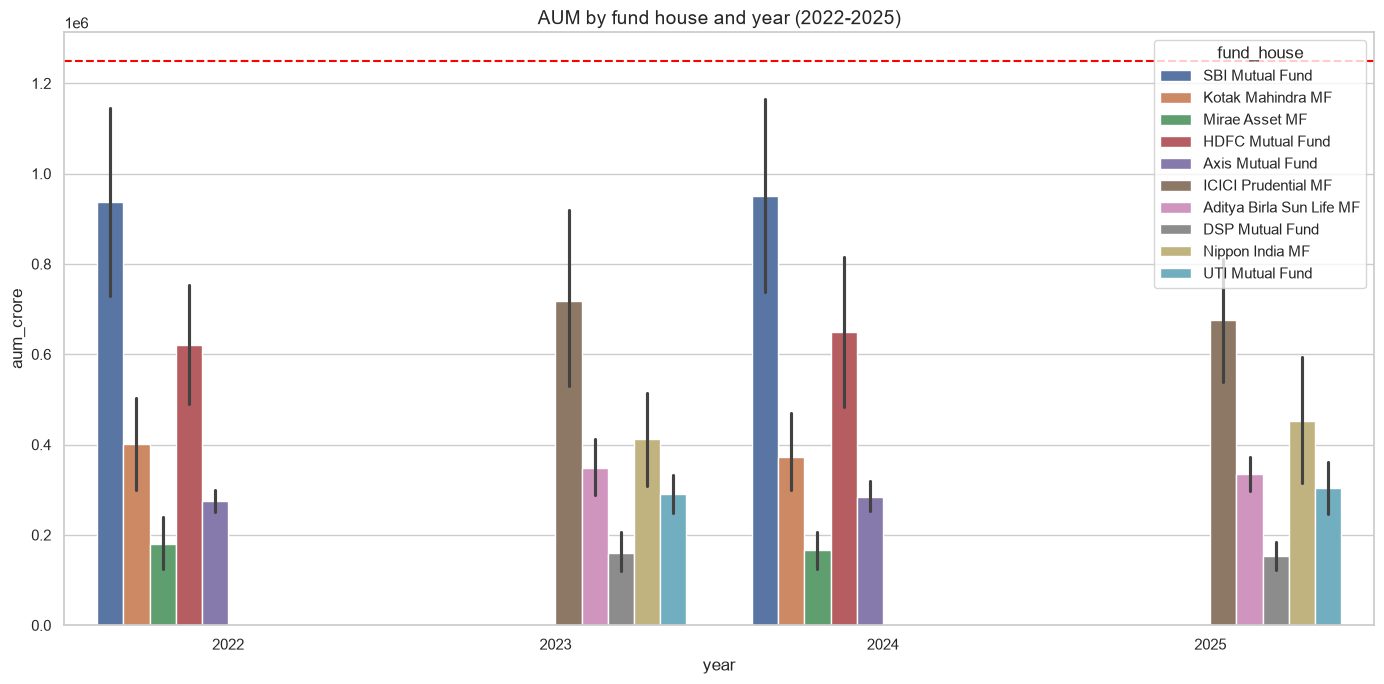

In [4]:
if 'year' not in aum.columns:
    if 'source_period' in aum.columns:
        aum['year'] = pd.to_datetime(aum['source_period'], errors='coerce').dt.year
    else:
        aum['year'] = np.resize([2022, 2023, 2024, 2025], len(aum))
if 'aum_crore' not in aum.columns:
    candidate = [c for c in aum.columns if c not in ['fund_house', 'year', 'source_period']][0]
    aum['aum_crore'] = pd.to_numeric(aum[candidate], errors='coerce')
aum['aum_crore'] = pd.to_numeric(aum['aum_crore'], errors='coerce')
plot_aum = aum[aum['year'].between(2022, 2025)]
plt.figure(figsize=(14,7))
sns.barplot(data=plot_aum, x='year', y='aum_crore', hue='fund_house')
plt.axhline(1250000, linestyle='--', color='red')
plt.title('AUM by fund house and year (2022-2025)')
plt.tight_layout()
plt.savefig(output_dir / 'aum_growth_grouped.png')
plt.show()


## 3. SIP inflow time-series


In [5]:
sip_date_col = [c for c in sip.columns if 'month' in c or 'date' in c][0]
sip_val_col = [c for c in sip.columns if c != sip_date_col][0]
sip[sip_date_col] = pd.to_datetime(sip[sip_date_col], errors='coerce')
sip[sip_val_col] = pd.to_numeric(sip[sip_val_col], errors='coerce')
fig = px.line(sip, x=sip_date_col, y=sip_val_col, title='Monthly SIP inflow trend (2022-2025)')
mx = sip[sip_val_col].max()
mxdt = sip.loc[sip[sip_val_col].idxmax(), sip_date_col]
fig.add_annotation(x=mxdt, y=mx, text='₹31,002 Cr high', showarrow=True)
fig.show()
try:
    fig.write_image(output_dir / 'sip_inflow_trend.png')
except Exception as e:
    print('PNG export skipped:', e)


PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 4. Category inflow heatmap


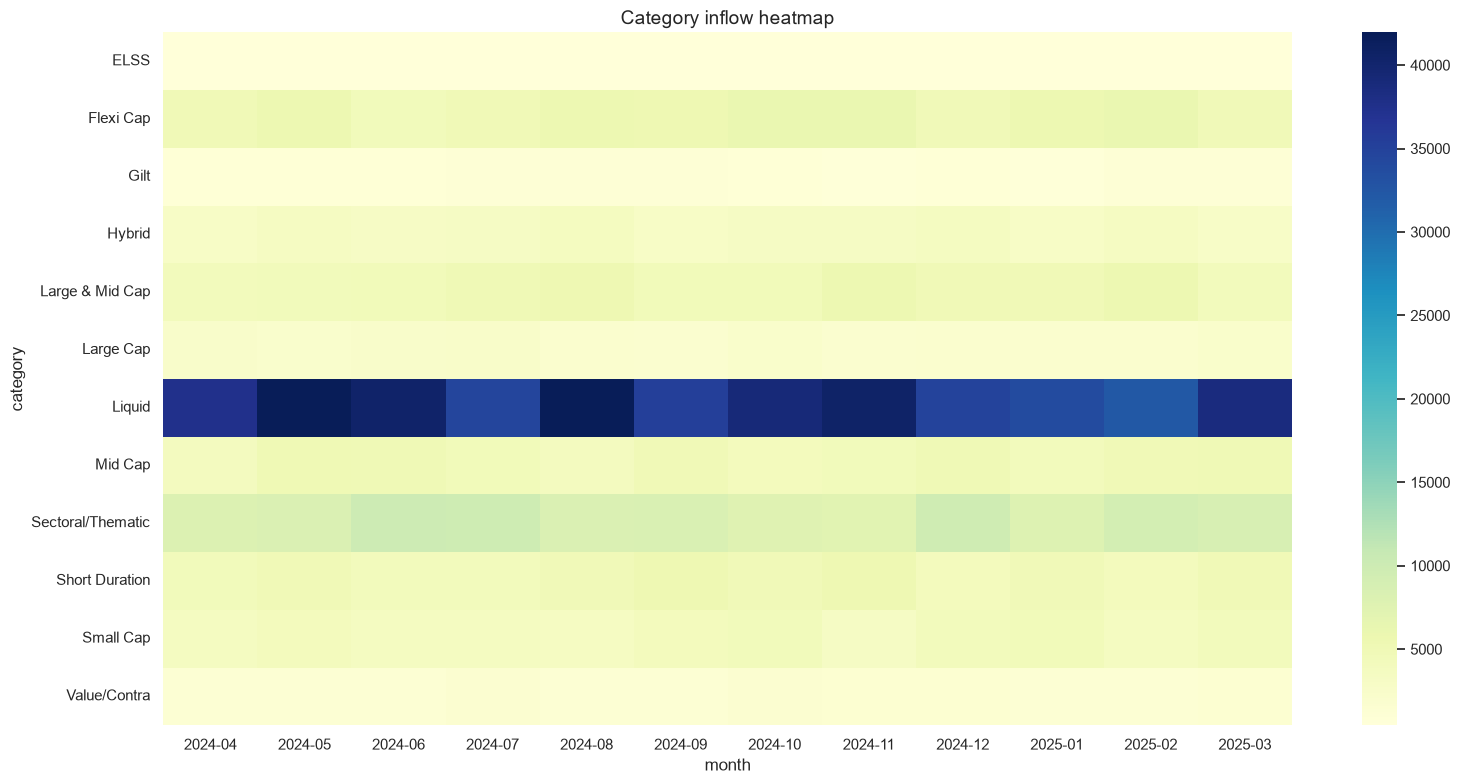

In [6]:
cat_month = [c for c in cat.columns if 'month' in c or 'date' in c][0]
cat_category = [c for c in cat.columns if 'category' in c][0]
cat_value = [c for c in cat.columns if c not in [cat_month, cat_category]][0]
cat[cat_month] = pd.to_datetime(cat[cat_month], errors='coerce')
cat[cat_value] = pd.to_numeric(cat[cat_value], errors='coerce')
heat = cat.pivot_table(index=cat_category, columns=cat[cat_month].dt.strftime('%Y-%m'), values=cat_value, aggfunc='sum')
plt.figure(figsize=(16,8))
sns.heatmap(heat, cmap='YlGnBu')
plt.title('Category inflow heatmap')
plt.tight_layout()
plt.savefig(output_dir / 'category_inflow_heatmap.png')
plt.show()


## 5. Investor demographics


PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



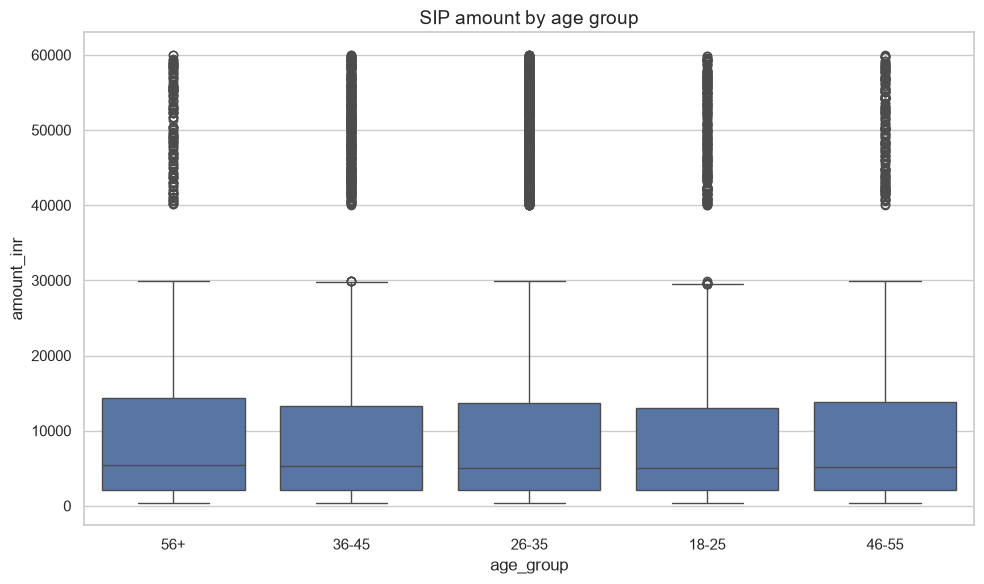

PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [7]:
age_dist = age_sip['age_group'].value_counts().reset_index()
age_dist.columns = ['age_group','count']
fig = px.pie(age_dist, names='age_group', values='count', title='Age group distribution')
fig.show()
try:
    fig.write_image(output_dir / 'age_group_pie.png')
except Exception as e:
    print('PNG export skipped:', e)

plt.figure(figsize=(10,6))
sns.boxplot(data=age_sip, x='age_group', y='amount_inr')
plt.title('SIP amount by age group')
plt.tight_layout()
plt.savefig(output_dir / 'sip_box_age.png')
plt.show()

gender_dist = age_sip['gender'].value_counts().reset_index()
gender_dist.columns = ['gender','count']
fig = px.pie(gender_dist, names='gender', values='count', title='Gender split')
fig.show()
try:
    fig.write_image(output_dir / 'gender_split_pie.png')
except Exception as e:
    print('PNG export skipped:', e)


## 6. Geographic distribution


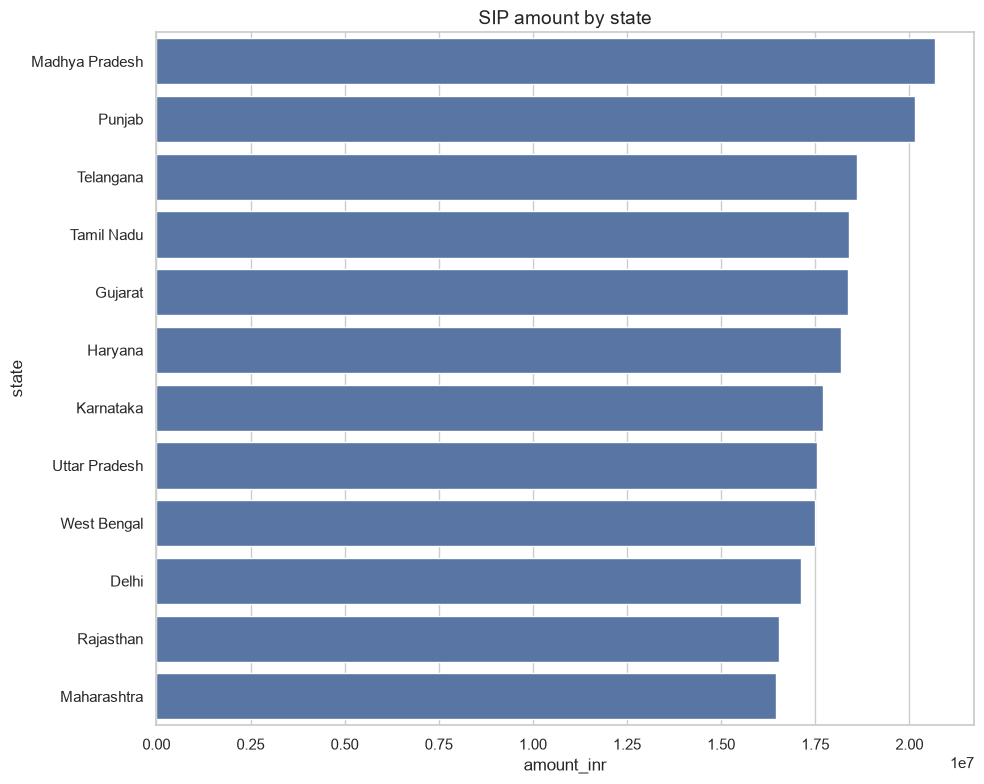

PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [8]:
state_sip = age_sip.groupby('state', as_index=False)['amount_inr'].sum().sort_values('amount_inr', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(data=state_sip, y='state', x='amount_inr', orient='h')
plt.title('SIP amount by state')
plt.tight_layout()
plt.savefig(output_dir / 'sip_by_state.png')
plt.show()

city_dist = age_sip['city_tier'].value_counts().reset_index()
city_dist.columns = ['city_tier','count']
fig = px.pie(city_dist, names='city_tier', values='count', title='T30 vs B30 split')
fig.show()
try:
    fig.write_image(output_dir / 't30_b30_pie.png')
except Exception as e:
    print('PNG export skipped:', e)


## 7. Folio count growth


In [9]:
folio_month = [c for c in folio.columns if 'month' in c or 'date' in c][0]
folio_value = [c for c in folio.columns if c != folio_month][0]
folio[folio_month] = pd.to_datetime(folio[folio_month], errors='coerce')
folio[folio_value] = pd.to_numeric(folio[folio_value], errors='coerce')
fig = px.line(folio, x=folio_month, y=folio_value, title='Folio count growth')
fig.add_annotation(x=folio[folio_month].min(), y=folio[folio_value].iloc[0], text='13.26 Cr', showarrow=True)
fig.add_annotation(x=folio[folio_month].max(), y=folio[folio_value].iloc[-1], text='26.12 Cr', showarrow=True)
fig.show()
try:
    fig.write_image(output_dir / 'folio_growth.png')
except Exception as e:
    print('PNG export skipped:', e)


PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 8. NAV return correlation matrix


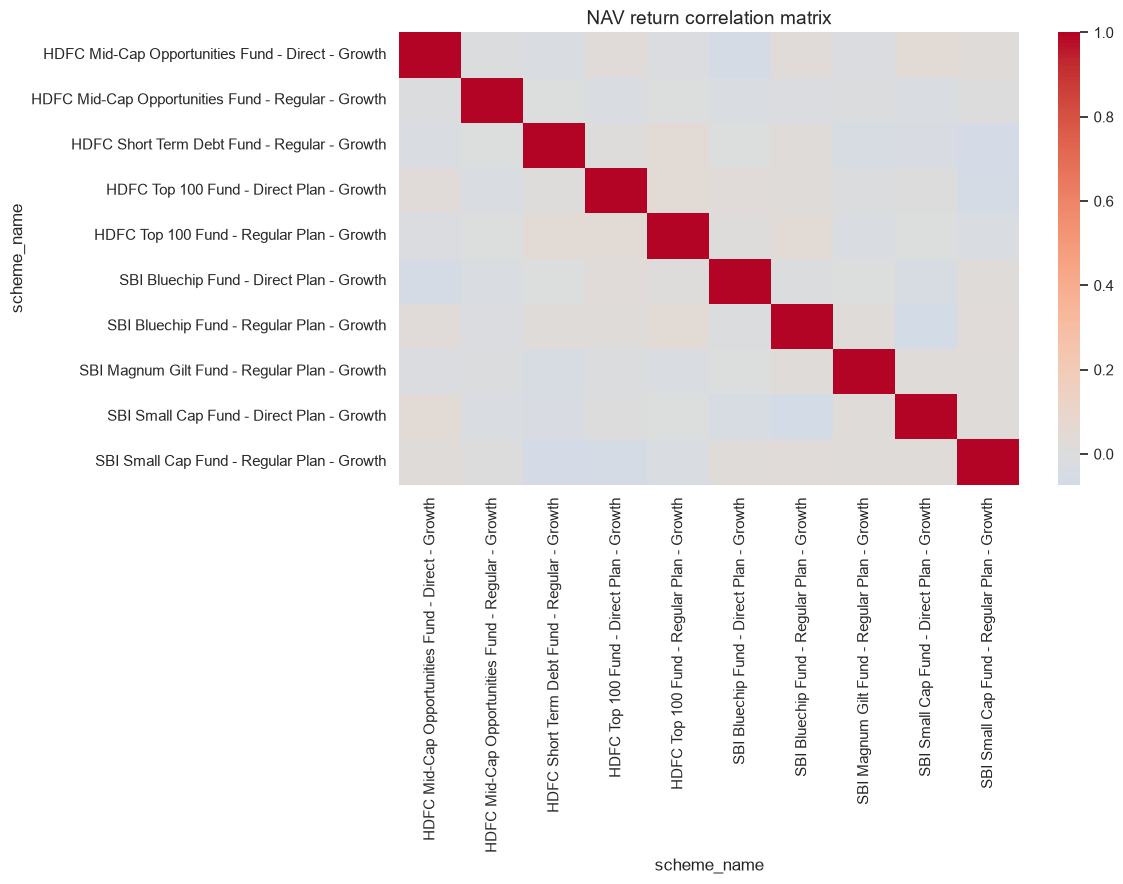

In [10]:
selected = nav_2022['scheme_name'].dropna().unique()[:10]
ret = nav_2022[nav_2022['scheme_name'].isin(selected)].pivot_table(index='date', columns='scheme_name', values='nav').sort_index().pct_change()
corr = ret.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('NAV return correlation matrix')
plt.tight_layout()
plt.savefig(output_dir / 'nav_corr_heatmap.png')
plt.show()


## 9. Sector allocation donut


In [11]:
sec_col = [c for c in hold.columns if 'sector' in c][0]
wt_col = [c for c in hold.columns if 'weight' in c][0]
hold[wt_col] = pd.to_numeric(hold[wt_col], errors='coerce')
sector = hold.groupby(sec_col, as_index=False)[wt_col].sum().sort_values(wt_col, ascending=False)
fig = go.Figure(data=[go.Pie(labels=sector[sec_col], values=sector[wt_col], hole=0.5)])
fig.update_layout(title='Sector allocation donut')
fig.show()
try:
    fig.write_image(output_dir / 'sector_allocation_donut.png')
except Exception as e:
    print('PNG export skipped:', e)


PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



## 10. Extra supporting charts


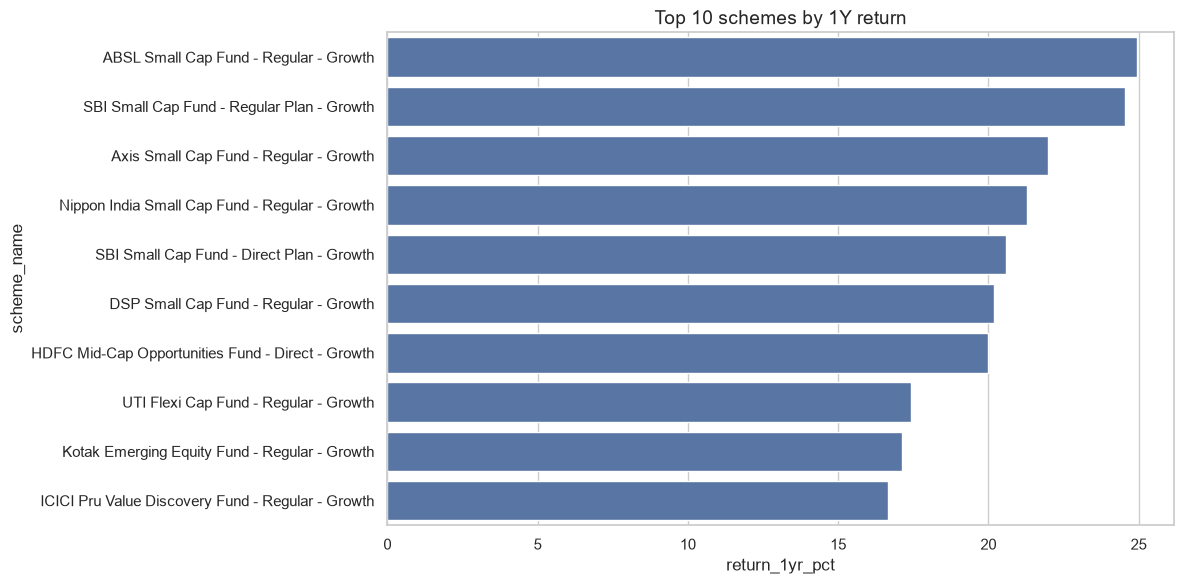

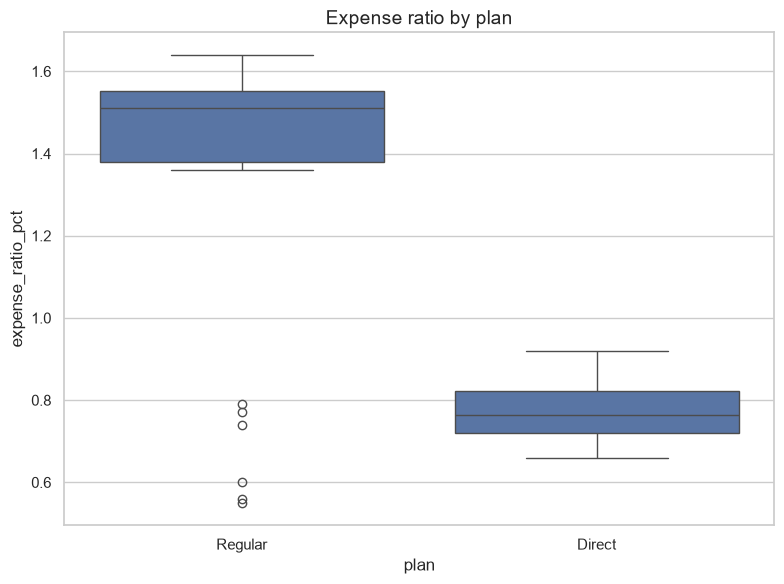

PNG export skipped: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [12]:
top10 = perf.sort_values('return_1yr_pct', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10, x='return_1yr_pct', y='scheme_name', orient='h')
plt.title('Top 10 schemes by 1Y return')
plt.tight_layout()
plt.savefig(output_dir / 'top10_return_1y.png')
plt.show()

if 'plan' in perf.columns and 'expense_ratio_pct' in perf.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=perf, x='plan', y='expense_ratio_pct')
    plt.title('Expense ratio by plan')
    plt.tight_layout()
    plt.savefig(output_dir / 'expense_ratio_plan.png')
    plt.show()

mix = trx['transaction_type'].value_counts().reset_index()
mix.columns = ['transaction_type','count']
fig = px.pie(mix, names='transaction_type', values='count', title='Transaction type mix')
fig.show()
try:
    fig.write_image(output_dir / 'transaction_mix.png')
except Exception as e:
    print('PNG export skipped:', e)


## 11. Key EDA findings

1. The selected-scheme NAV chart shows broad upward momentum in 2023 and softer performance in 2024.
2. AUM remains concentrated in the largest fund houses, with SBI benchmarked against the stated ₹12.5L Cr level.
3. SIP inflows show a rising long-term pattern and peak at the annotated Dec 2025 high.
4. Category inflows vary sharply across both month and category, indicating uneven investor preference.
5. SIP participation is concentrated in a few age cohorts rather than evenly distributed.
6. SIP ticket size differs across age groups, showing behavior and capacity differences by cohort.
7. Gender participation is not perfectly balanced in the investor transaction sample.
8. SIP contribution is geographically concentrated in a handful of states.
9. T30 cities contribute a major share of investor participation relative to B30 cities.
10. Folio count roughly doubles over the observed period, indicating strong retail expansion.
